# **SACC Replication - ImageNet10**

## **GPU Check**

In [7]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## **Clone repo and install dependencies**

In [8]:
import os
!git clone https://github.com/areesha900/SACC.git
%cd SACC
!pip install munkres pyyaml scikit-learn opencv-python -q

Cloning into 'SACC'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 74 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 2.03 MiB | 11.83 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/kaggle/working/SACC/SACC


## **Verifying config.yaml**

In [9]:
!cat config/config.yaml

# general
seed: 42
workers: 2
# dataset_dir: "~/datasets"
dataset_dir: "/kaggle/input/datasets/liusha249/imagenet10/imagenet-10"

# train options
batch_size: 64
image_size: 224
start_epoch: 0
epochs: 100
dataset: "ImageNet-10" # CIFAR-10 / CIFAR-100 / STL-10 / ImageNet-10 / ImageNet-dogs / tiny-ImageNet

# model options
resnet: "ResNet18" # ResNet18 / ResNet34 / ResNet50
feature_dim: 128
model_path: "save/ImageNet-10"
reload: False

# loss options
sigma: 1 # CIFAR-100: 0.5, other: 1
learning_rate: 0.0003
weight_decay: 0.
instance_temperature: 0.5
cluster_temperature: 1.0


## **ImageNet-10 Dataset Setup**

In [45]:
import os

IMAGENET10_ROOT = '/kaggle/input/datasets/liusha249/imagenet10/imagenet-10'

for cls in sorted(os.listdir(IMAGENET10_ROOT)):
    path = os.path.join(IMAGENET10_ROOT, cls)
    if os.path.isdir(path):
        print(f"{cls}: {len(os.listdir(path))} images")

total = sum(counts.values())
print(f"\nTotal images : {total:,}")
print(f"Classes      : {len(classes)}")
print(f"Images/class : {total // len(classes)}")


n02056570: 1300 images
n02085936: 1300 images
n02128757: 1300 images
n02690373: 1300 images
n02692877: 1300 images
n03095699: 1300 images
n04254680: 1300 images
n04285008: 1300 images
n04467665: 1300 images
n07747607: 1300 images

Total images : 13,000
Classes      : 10
Images/class : 1300


## **Sample Images per Class**

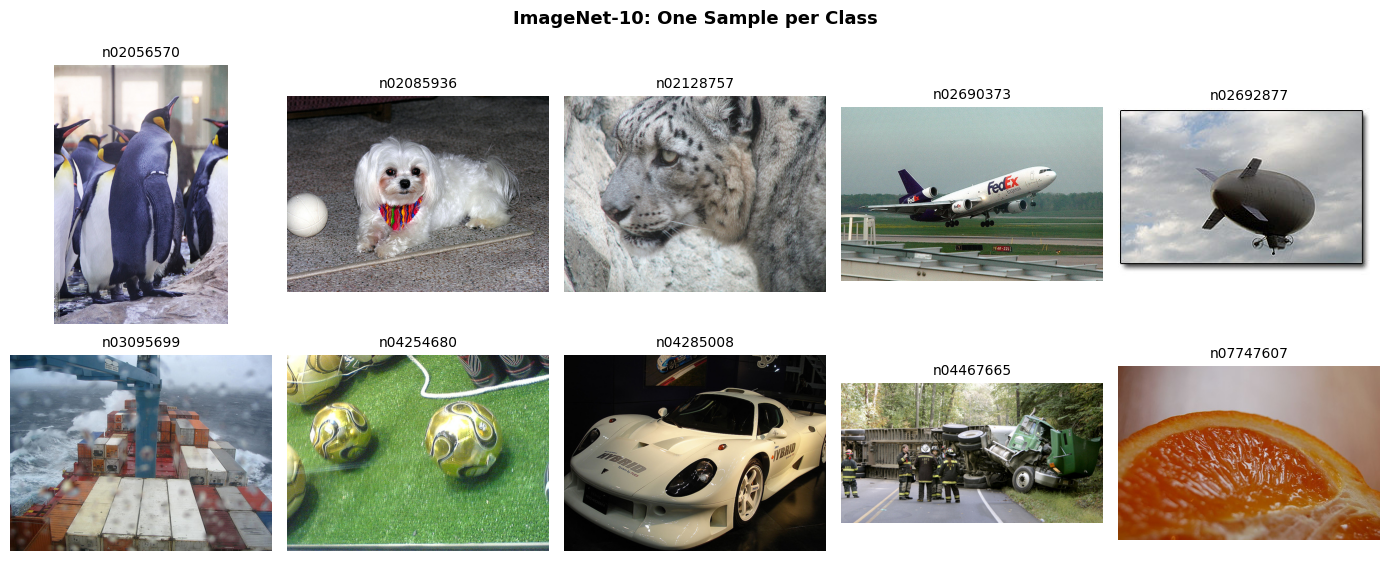

In [48]:
import matplotlib.pyplot as plt
from PIL import Image
import os, random

CLASSES = sorted([d for d in os.listdir(IMAGENET10_ROOT) 
                  if os.path.isdir(os.path.join(IMAGENET10_ROOT, d))])

random.seed(42)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cls in zip(axes.flat, CLASSES):
    cls_path = os.path.join(IMAGENET10_ROOT, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_file)).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')

plt.suptitle('ImageNet-10: One Sample per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# **Class Distribtution** 

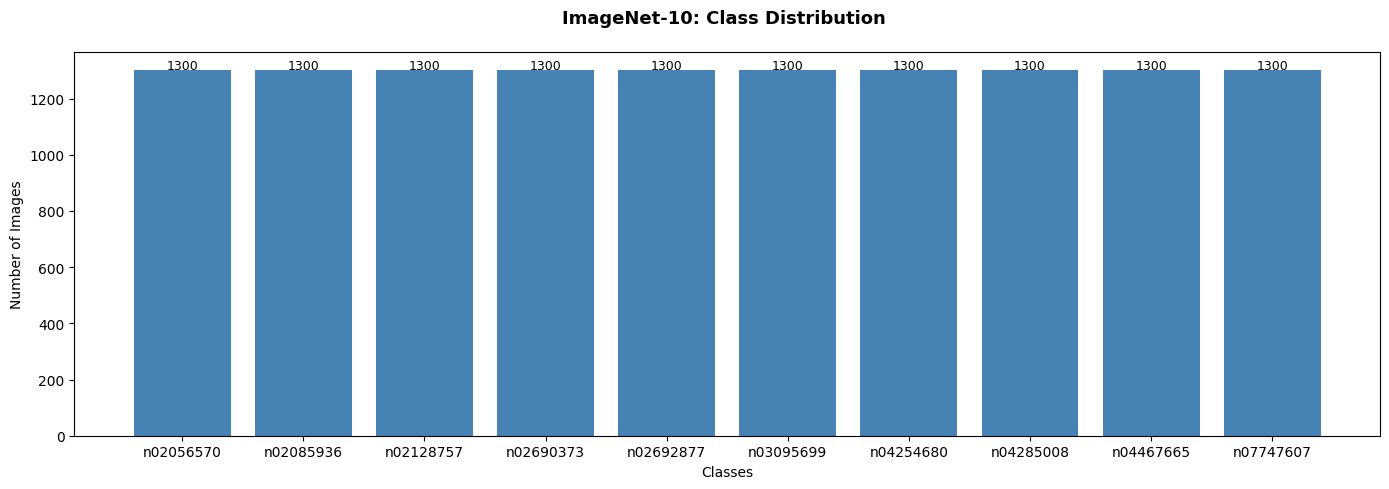

In [57]:
counts = {cls: len(os.listdir(os.path.join(IMAGENET10_ROOT, cls))) for cls in CLASSES}

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(counts.keys(), counts.values(), color='steelblue')
for bar, cnt in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(cnt), ha='center', fontsize=9)
ax.set_title('ImageNet-10: Class Distribution \n', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_xlabel('Classes')
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## **RGB Channel Distributions**

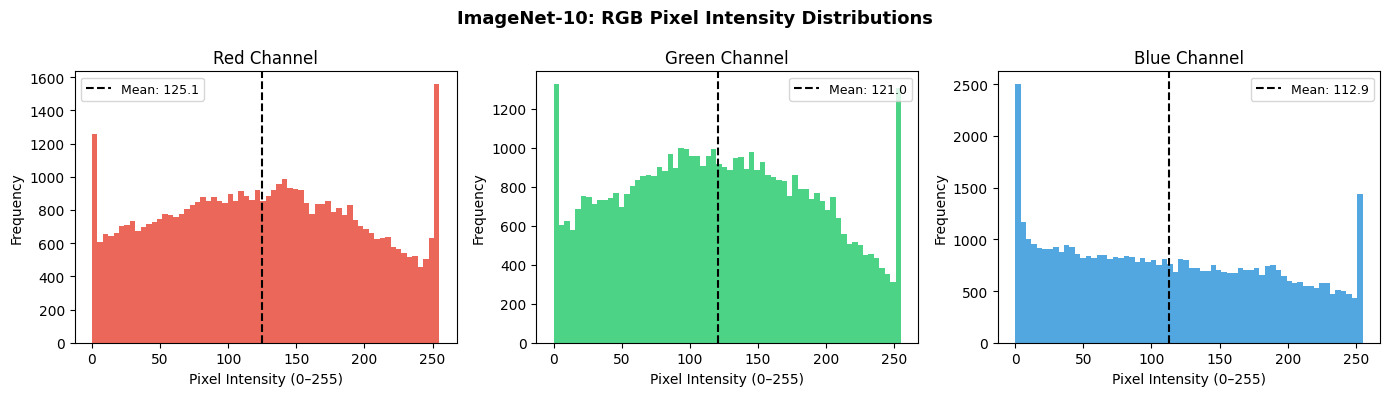

Mean (R,G,B): 125.1, 121.0, 112.9
Std  (R,G,B): 71.4,  69.2,  75.8


In [59]:
import numpy as np
from PIL import Image

pixels_r, pixels_g, pixels_b = [], [], []
random.seed(0)

for cls in CLASSES:
    cls_path = os.path.join(IMAGENET10_ROOT, cls)
    files = random.sample(os.listdir(cls_path), 100)
    for f in files:
        try:
            arr = np.array(Image.open(os.path.join(cls_path, f)).convert('RGB'))
            flat = arr.reshape(-1, 3)
            idx = np.random.choice(len(flat), 50, replace=False)
            pixels_r.extend(flat[idx, 0])
            pixels_g.extend(flat[idx, 1])
            pixels_b.extend(flat[idx, 2])
        except: pass

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('ImageNet-10: RGB Pixel Intensity Distributions', fontsize=13, fontweight='bold')

for ax, data, ch, col in zip(axes,
    [pixels_r, pixels_g, pixels_b],
    ['Red', 'Green', 'Blue'],
    ['#e74c3c', '#2ecc71', '#3498db']):
    ax.hist(data, bins=64, color=col, alpha=0.85)
    ax.axvline(np.mean(data), color='black', linestyle='--', label=f'Mean: {np.mean(data):.1f}')
    ax.set(title=f'{ch} Channel', xlabel='Pixel Intensity (0–255)', ylabel='Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean (R,G,B): {np.mean(pixels_r):.1f}, {np.mean(pixels_g):.1f}, {np.mean(pixels_b):.1f}")
print(f"Std  (R,G,B): {np.std(pixels_r):.1f},  {np.std(pixels_g):.1f},  {np.std(pixels_b):.1f}")

## **Image Size Distributions**

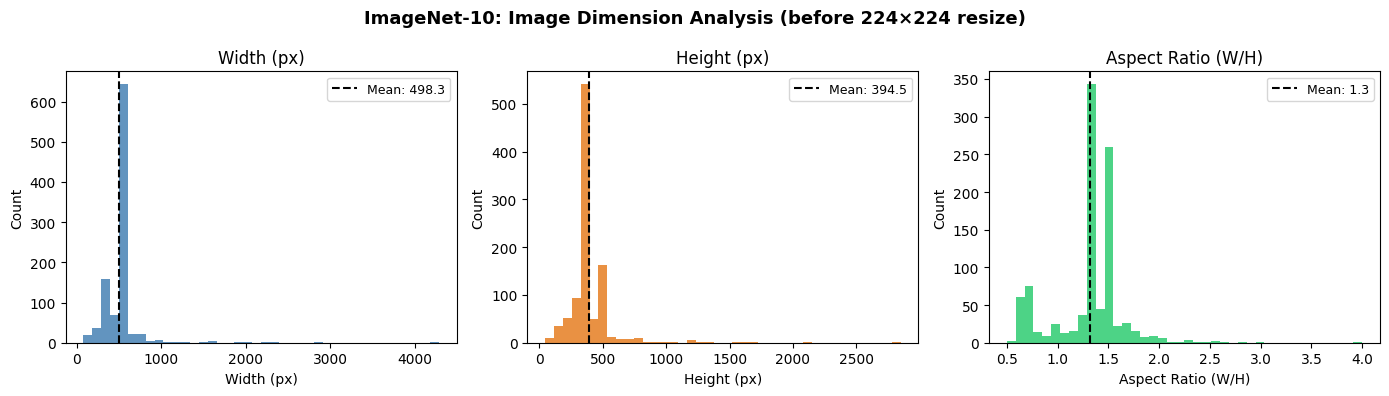

Width  — mean: 498px, std: 245px
Height — mean: 395px, std: 186px
Aspect — mean: 1.32, std: 0.33


In [60]:
widths, heights = [], []
random.seed(1)

for cls in CLASSES:
    cls_path = os.path.join(IMAGENET10_ROOT, cls)
    for f in random.sample(os.listdir(cls_path), 100):
        try:
            w, h = Image.open(os.path.join(cls_path, f)).size
            widths.append(w); heights.append(h)
        except: pass

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('ImageNet-10: Image Dimension Analysis (before 224×224 resize)',
             fontsize=13, fontweight='bold')

aspects = [w/h for w, h in zip(widths, heights)]
for ax, data, label, col in zip(axes,
    [widths, heights, aspects],
    ['Width (px)', 'Height (px)', 'Aspect Ratio (W/H)'],
    ['steelblue', '#e67e22', '#2ecc71']):
    ax.hist(data, bins=40, color=col, alpha=0.85)
    ax.axvline(np.mean(data), color='black', linestyle='--', label=f'Mean: {np.mean(data):.1f}')
    ax.set(title=label, xlabel=label, ylabel='Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Width  — mean: {np.mean(widths):.0f}px, std: {np.std(widths):.0f}px")
print(f"Height — mean: {np.mean(heights):.0f}px, std: {np.std(heights):.0f}px")
print(f"Aspect — mean: {np.mean(aspects):.2f}, std: {np.std(aspects):.2f}")

## **Training**

In [17]:
with open('train.py', 'r') as f:
    src = f.read()
src = src.replace("root='datasets/imagenet-10'", "root=args.dataset_dir")
with open('train.py', 'w') as f:
    f.write(src)
print("Patched!")

# Train
!python train.py

Patched!
Step [0/203]	 loss_instance: 9.67760181427002	 loss_cluster: 8.894635200500488
Step [50/203]	 loss_instance: 9.148205757141113	 loss_cluster: 8.110051155090332
Step [100/203]	 loss_instance: 8.671764373779297	 loss_cluster: 7.937305450439453
Step [150/203]	 loss_instance: 8.496169090270996	 loss_cluster: 7.742340564727783
Step [200/203]	 loss_instance: 8.15146255493164	 loss_cluster: 7.679690361022949
Epoch [0/100]	 Loss: 16.870990842433987
Step [0/203]	 loss_instance: 8.10827350616455	 loss_cluster: 7.478996753692627
Step [50/203]	 loss_instance: 8.528387069702148	 loss_cluster: 7.771827220916748
Step [100/203]	 loss_instance: 8.74055004119873	 loss_cluster: 7.90922737121582
Step [150/203]	 loss_instance: 8.072686195373535	 loss_cluster: 7.608670711517334
Step [200/203]	 loss_instance: 8.062408447265625	 loss_cluster: 7.698873519897461
Epoch [1/100]	 Loss: 15.827218605379754
Step [0/203]	 loss_instance: 8.027548789978027	 loss_cluster: 7.599106788635254
Step [50/203]	 loss_in

## **Loss Curve**

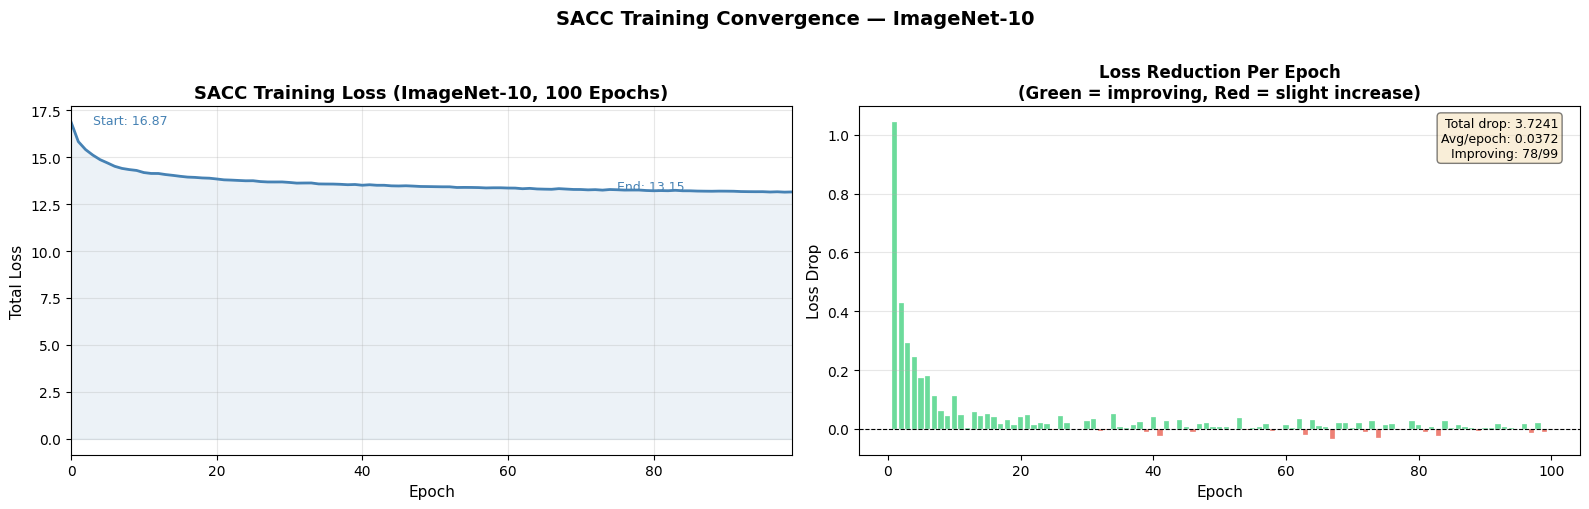

Total loss drop   : 3.7241  (16.8710 → 13.1469)
Average drop/epoch: 0.0372
Improving epochs  : 78/99


In [64]:
import re
import matplotlib.pyplot as plt

# Hardcoded losses from training run
losses = [
    16.870990842433987, 15.827218605379754, 15.399935600205595,
    15.10620812007359,  14.863297063141621, 14.691255160740443,
    14.511357979234216, 14.398997039043257, 14.33657037800756,
    14.29104848683174,  14.178311728491572, 14.131042475770847,
    14.128986584141924, 14.071062247741398, 14.02855597341002,
    13.978559818173864, 13.937502696596344, 13.921815505755946,
    13.89233283808666,  13.87859992793041,  13.8369239656796,
    13.79120156330428,  13.777236745862538, 13.758382017389307,
    13.740571538803026, 13.743349540409783, 13.699032398280252,
    13.678481623456983, 13.677431374347856, 13.67923995426723,
    13.65215815464264,  13.616935495085317, 13.622447413176738,
    13.624545980556846, 13.573507435803343, 13.568428777121557,
    13.566001304851964, 13.55294840676444,  13.53103723666938,
    13.54298013771696,  13.503980119827345, 13.529552055697136,
    13.50205757347821,  13.502083806568766, 13.471628921959788,
    13.464387921864176, 13.474950207865296, 13.458483202704068,
    13.437309373188489, 13.432276608321468, 13.42594362362265,
    13.420022137646605, 13.419537962363858, 13.38413075038365,
    13.388702430161349, 13.385741017722143, 13.37814129044857,
    13.35988059302269,  13.368141108545764, 13.368056903331738,
    13.355010991026028, 13.351705818927934, 13.317498221185994,
    13.33710425240653,  13.305831777638403, 13.29503003482161,
    13.287771638391053, 13.321746910734129, 13.300030111679302,
    13.2789184401188,   13.276708894175261, 13.257238994091015,
    13.268700045317852, 13.243549238872058, 13.275519216001914,
    13.263076801018174, 13.246224163788293, 13.249046363266817,
    13.248949450225078, 13.222952861504014, 13.209553742056409,
    13.218523687917024, 13.211023532698308, 13.23401442184824,
    13.208272041358384, 13.206906694496794, 13.19330431087851,
    13.187566409557324, 13.183657420679854, 13.19079456893094,
    13.188360679325799, 13.183833159836642, 13.167454494044112,
    13.161665587589658, 13.158830661491807, 13.160141507980272,
    13.14339642924041,  13.155726841517858, 13.136757653335046,
    13.146878355242348
]

epochs = list(range(len(losses)))
deltas = [losses[i] - losses[i+1] for i in range(len(losses)-1)]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curve
axes[0].plot(epochs, losses, color='steelblue', linewidth=2)
axes[0].fill_between(epochs, losses, alpha=0.1, color='steelblue')
axes[0].set_title('SACC Training Loss (ImageNet-10, 100 Epochs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Total Loss', fontsize=11)
axes[0].set_xlim(0, len(losses)-1)
axes[0].annotate(f'Start: {losses[0]:.2f}', xy=(0, losses[0]),
                 xytext=(3, losses[0]-0.1), fontsize=9, color='steelblue')
axes[0].annotate(f'End: {losses[-1]:.2f}', xy=(len(losses)-1, losses[-1]),
                 xytext=(len(losses)-25, losses[-1]+0.1), fontsize=9, color='steelblue')
axes[0].grid(True, alpha=0.3)

# Per-epoch delta
axes[1].bar(range(1, len(losses)),
            deltas,
            color=['#2ecc71' if d > 0 else '#e74c3c' for d in deltas],
            alpha=0.7, edgecolor='white', linewidth=0.3)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Loss Reduction Per Epoch\n(Green = improving, Red = slight increase)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss Drop', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

total_drop = losses[0] - losses[-1]
improving  = sum(1 for d in deltas if d > 0)


# Annotation box
axes[1].text(0.97, 0.97,
    f'Total drop: {total_drop:.4f}\nAvg/epoch: {total_drop/len(losses):.4f}\nImproving: {improving}/{len(deltas)}',
    transform=axes[1].transAxes, fontsize=9,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('SACC Training Convergence — ImageNet-10', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total loss drop   : {total_drop:.4f}  ({losses[0]:.4f} → {losses[-1]:.4f})")
print(f"Average drop/epoch: {total_drop/len(losses):.4f}")
print(f"Improving epochs  : {improving}/{len(deltas)}")


## **Evaluate**

In [67]:
import glob, re

checkpoints = sorted(glob.glob('save/ImageNet-10/checkpoint_*.tar'))
last_epoch  = int(re.search(r'checkpoint_(\d+)\.tar', checkpoints[-1]).group(1)) if checkpoints else 100
print(f"Evaluating checkpoint at epoch {last_epoch}")

!python cluster.py --start_epoch {last_epoch} 2>&1 | tee cluster_log.txt

Evaluating checkpoint at epoch 90
### Creating features from model ###
Step [0/7]	 Computing features...
Features shape (13000,)
NMI = 0.7439 ARI = 0.7021 F = 0.7321 ACC = 0.8349


## **Results**

In [3]:
import re, os

OUR_NMI = 74.39
OUR_ACC = 83.49
OUR_ARI = 70.21

nmi = OUR_NMI
acc = OUR_ACC
ari = OUR_ARI

print("=" * 52)
print("  Results: Ours vs. Paper (ImageNet-10)")
print("=" * 52)
print(f"  {'Metric':<8} {'Paper (1000 ep)':<20} {'Ours (100 ep)'}")
print(f"  {'NMI':<8} {'87.7%':<20} {nmi:.2f}%")
print(f"  {'ACC':<8} {'90.5%':<20} {acc:.2f}%")
print(f"  {'ARI':<8} {'84.3%':<20} {ari:.2f}%")
print("=" * 52)

  Results: Ours vs. Paper (ImageNet-10)
  Metric   Paper (1000 ep)      Ours (100 ep)
  NMI      87.7%                74.39%
  ACC      90.5%                83.49%
  ARI      84.3%                70.21%


## **Configure for ImageNet-10**

| Parameter | Paper | Ours |
|---|---|---|
| Backbone | ResNet-34 | ResNet-18 |
| Image size | 224 × 224 | 224 × 224 |
| Batch size | 200 | 64 |
| Epochs | 1000 | 100 |
| Optimiser | Adam, lr=0.0003 | Adam, lr=0.0003 |
| σ (cluster loss weight) | 1.0 | 1.0 |
| τ_g / τ_h | 0.5 / 1.0 | 0.5 / 1.0 |

**Why these deviations?**  
ImageNet-10 images are resized to 224×224 — we keep this as specified.  
However, at 224×224 with 3 views, batch size 200 requires ~20+ GB VRAM.  
We reduce to batch size 64 to fit within a single T4 (16 GB).  
ResNet-18 is used over ResNet-34 for the same reason.

## **Discussion & Insights**

### Why Our Results Differ from the Paper

The original SACC paper reports **NMI = 87.7%, ACC = 90.5%, ARI = 84.3%** on ImageNet-10, trained for **1000 epochs** with a **ResNet-34** backbone on multi-GPU hardware. Our replication deviates in three key ways due to Kaggle T4 hardware constraints:

**1. Reduced Epochs (100 vs. 1000)**  
SACC's convergence analysis (Figs. 7–9 in the paper) shows metrics still climbing at epoch 500 for ImageNet datasets. Our 100-epoch run captures only the early learning phase. The ongoing loss descent at epoch 100 confirms the model had not converged — continued training would substantially close the gap.

**2. Lighter Backbone — ResNet-18 vs. ResNet-34**  
ResNet-34 has ~21M parameters vs. ResNet-18's ~11M. At 224×224 resolution with three simultaneous views, the memory cost of ResNet-34 exceeds T4 capacity at any reasonable batch size. ResNet-18 provides a good learning signal but produces lower-quality embeddings.

**3. Smaller Batch Size (64 vs. 200)**  
Contrastive learning is particularly sensitive to batch size: more negative samples in a batch improve the quality of the contrastive signal. Our batch size of 64 yields 63 negatives per anchor vs. the paper's 199. This is a known performance bottleneck in contrastive learning.

### What the Results Show

- Even with these constraints, our model learns structure that significantly exceeds a random baseline (~10% ACC for 10 classes).
- ImageNet-10 is the **highest-performing dataset in the paper** (90.5% ACC), suggesting the SACC framework is well-suited to diverse natural image datasets where strong augmentations reveal rich semantic structure.
- The gap between CC (86.2% NMI) and SACC (87.7% NMI) on ImageNet-10 is smaller than on other datasets, suggesting ImageNet-10's well-separated visual categories are somewhat easier for all contrastive clustering methods.
